# Kakao Quality Dashboard

이 노트북은 `kakao_raw`에 적재된 Kakao 장소 검색 결과가 실제 분석/서비스에 어느 정도 쓸 수 있는지 확인한다.

Kakao raw는 공식 행정 데이터가 아니라 검색 API 결과다. 따라서 최종 score의 고정 근거라기보다는 주변 편의시설/POI 검색 품질과 커버리지 확인에 가깝다.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sqlalchemy import text

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEOUL_BBOX = {
    "min_lon": 126.7,
    "max_lon": 127.2,
    "min_lat": 37.4,
    "max_lat": 37.75,
}

KOREAN_FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
if KOREAN_FONT_PATH.exists():
    fm.fontManager.addfont(str(KOREAN_FONT_PATH))
    KOREAN_FONT = fm.FontProperties(fname=str(KOREAN_FONT_PATH))
    KOREAN_FONT_NAME = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
    KOREAN_FONT_NAME = "DejaVu Sans"

sns.set_theme(style="whitegrid", font=KOREAN_FONT_NAME, rc={"axes.unicode_minus": False})
plt.rcParams["font.family"] = KOREAN_FONT_NAME
plt.rcParams["axes.unicode_minus"] = False


def apply_korean_font(ax):
    if KOREAN_FONT is None:
        return ax
    ax.title.set_fontproperties(KOREAN_FONT)
    ax.xaxis.label.set_fontproperties(KOREAN_FONT)
    ax.yaxis.label.set_fontproperties(KOREAN_FONT)
    for text in ax.get_xticklabels() + ax.get_yticklabels() + ax.texts:
        text.set_fontproperties(KOREAN_FONT)
    return ax


def add_point_quality_columns(gdf):
    result = gdf.copy()
    result["lon"] = result.geometry.x
    result["lat"] = result.geometry.y
    result["within_seoul_bbox"] = (
        result["lon"].between(SEOUL_BBOX["min_lon"], SEOUL_BBOX["max_lon"])
        & result["lat"].between(SEOUL_BBOX["min_lat"], SEOUL_BBOX["max_lat"])
    )
    result["lon_round6"] = result["lon"].round(6)
    result["lat_round6"] = result["lat"].round(6)
    return result


from src.database.postgresql import engine

FIGURE_DIR = PROJECT_ROOT / "analysis" / "figures" / "raw" / "kakao"
TABLE_DIR = PROJECT_ROOT / "analysis" / "tables" / "raw" / "kakao"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

KAKAO_CATEGORY_CODE_NAME = {
    "MT1": "대형마트",
    "CS2": "편의점",
    "PS3": "어린이집·유치원",
    "SC4": "학교",
    "PK6": "주차장",
    "SW8": "지하철역",
    "BK9": "은행",
    "CT1": "문화시설",
    "PO3": "공공기관",
    "AT4": "관광명소",
    "FD6": "음식점",
    "CE7": "카페",
    "HP8": "병원",
    "PM9": "약국",
}

## 1. kakao_raw 적재 상태 확인

`kakao_raw`에 어떤 카테고리 검색 결과가 저장되어 있는지 확인한다. `fetched_at`은 DB 적재 시점이고, Kakao 장소 자체의 최신 수정일은 현재 저장되어 있지 않다.

In [2]:
kakao_status_sql = '''
SELECT
    query_key,
    COUNT(*) AS row_count,
    COUNT(geom) AS geom_count,
    MIN(fetched_at) AS first_fetched_at,
    MAX(fetched_at) AS last_fetched_at
FROM kakao_raw
GROUP BY query_key
ORDER BY row_count DESC
'''

try:
    kakao_status = pd.read_sql(kakao_status_sql, engine)
    kakao_status["category_code"] = kakao_status["query_key"].str.replace("category=", "", regex=False)
    kakao_status["category_name_ko"] = kakao_status["category_code"].map(KAKAO_CATEGORY_CODE_NAME)
    display(kakao_status)
    kakao_status.to_csv(TABLE_DIR / "kakao_raw_query_key_status.csv", index=False, encoding="utf-8-sig")
except Exception as e:
    kakao_status = pd.DataFrame()
    print("kakao_raw 조회 실패:", e)

,query_key,row_count,geom_count,first_fetched_at,last_fetched_at,category_code,category_name_ko
0,category=HP8,1066,1066,2026-06-24 06:37:19.033076,2026-06-24 06:37:19.033076,HP8,병원
1,category=PM9,1061,1061,2026-06-24 06:38:49.979128,2026-06-24 06:38:49.979128,PM9,약국
2,category=PS3,1036,1036,2026-06-24 06:23:05.214625,2026-06-24 06:23:05.214625,PS3,어린이집·유치원
3,category=SC4,995,995,2026-06-24 06:24:33.948289,2026-06-24 06:24:33.948289,SC4,학교
4,category=FD6,970,970,2026-06-24 06:34:22.333174,2026-06-24 06:34:22.333174,FD6,음식점
5,category=CE7,835,835,2026-06-24 06:35:52.538530,2026-06-24 06:35:52.538530,CE7,카페
6,category=PO3,767,767,2026-06-24 06:31:47.416311,2026-06-24 06:31:47.416311,PO3,공공기관
7,category=MT1,608,608,2026-06-24 06:20:30.636184,2026-06-24 06:20:30.636184,MT1,대형마트
8,category=CT1,549,549,2026-06-24 06:30:30.387318,2026-06-24 06:30:30.387318,CT1,문화시설
9,category=BK9,524,524,2026-06-24 06:29:06.729789,2026-06-24 06:29:06.729789,BK9,은행


## 2. kakao_raw GeoDataFrame 로드

Kakao raw의 point geometry와 properties를 불러온다. 이후 품질 검사는 이 GeoDataFrame을 기준으로 한다.

In [3]:
kakao_sql = '''
SELECT
    id AS kakao_raw_id,
    query_key,
    properties,
    fetched_at,
    geom
FROM kakao_raw
'''

try:
    kakao_gdf = gpd.read_postgis(kakao_sql, engine, geom_col="geom", crs="EPSG:4326")
    print("kakao_raw rows:", len(kakao_gdf))
    display(kakao_gdf.head())
except Exception as e:
    kakao_gdf = gpd.GeoDataFrame()
    print("kakao_raw GeoDataFrame 로드 실패:", e)

kakao_raw rows: 9624


,kakao_raw_id,query_key,properties,fetched_at,geom
0,1,category=MT1,"{'name': '이마트에브리데이 관산동점', 'phone': '031-969-96...",2026-06-24 06:20:30.636184,POINT (126.86545 37.68995)
1,2,category=MT1,"{'name': '벽제농협 로컬푸드직매장', 'phone': '031-962-187...",2026-06-24 06:20:30.636184,POINT (126.86391 37.68721)
2,3,category=MT1,"{'name': '고양축협하나로마트 본점', 'phone': '031-965-001...",2026-06-24 06:20:30.636184,POINT (126.84487 37.66545)
3,4,category=MT1,"{'name': '홈플러스익스프레스 고양성사점', 'phone': '031-968-...",2026-06-24 06:20:30.636184,POINT (126.83857 37.65839)
4,5,category=MT1,"{'name': '원당농협로컬푸드직매장 성사점', 'phone': '031-966-...",2026-06-24 06:20:30.636184,POINT (126.83851 37.65723)


## 3. Kakao 수집 방식 한계 정리

현재 `KakaoSource`는 서울 전체를 5x5 격자 중심점으로 나누고, 각 중심점에서 반경 8km, page 1~3, size 15로 카테고리 검색을 수행한다. 즉 카테고리별 최대 수집량은 격자 25개 x 45건 = 1125건 수준이고, API 검색 결과의 정렬/중복/반경 조건에 영향을 받는다.

In [4]:
kakao_collection_design = pd.DataFrame([
    {"item": "grid_count", "value": 25, "meaning": "서울 5x5 격자 중심점"},
    {"item": "radius_m", "value": 8000, "meaning": "각 격자 중심점 반경 8km 검색"},
    {"item": "pages_per_grid", "value": 3, "meaning": "Kakao category search page 1~3"},
    {"item": "size_per_page", "value": 15, "meaning": "page당 최대 15건"},
    {"item": "max_raw_hits_per_category_before_clean", "value": 25 * 3 * 15, "meaning": "카테고리별 이론상 최대 검색 결과"},
])

display(kakao_collection_design)
kakao_collection_design.to_csv(TABLE_DIR / "kakao_collection_design.csv", index=False, encoding="utf-8-sig")

,item,value,meaning
0,grid_count,25,서울 5x5 격자 중심점
1,radius_m,8000,각 격자 중심점 반경 8km 검색
2,pages_per_grid,3,Kakao category search page 1~3
3,size_per_page,15,page당 최대 15건
4,max_raw_hits_per_category_before_clean,1125,카테고리별 이론상 최대 검색 결과


## 4. category별 row 수 시각화

카테고리별 적재량 차이를 확인한다. Kakao는 검색 API라서 row 수가 시설 총량을 그대로 의미하지 않는다.

,query_key,row_count,category_code,category_name_ko
6,category=HP8,1066,HP8,병원
9,category=PM9,1061,PM9,약국
11,category=PS3,1036,PS3,어린이집·유치원
12,category=SC4,995,SC4,학교
5,category=FD6,970,FD6,음식점
2,category=CE7,835,CE7,카페
10,category=PO3,767,PO3,공공기관
7,category=MT1,608,MT1,대형마트
4,category=CT1,549,CT1,문화시설
1,category=BK9,524,BK9,은행


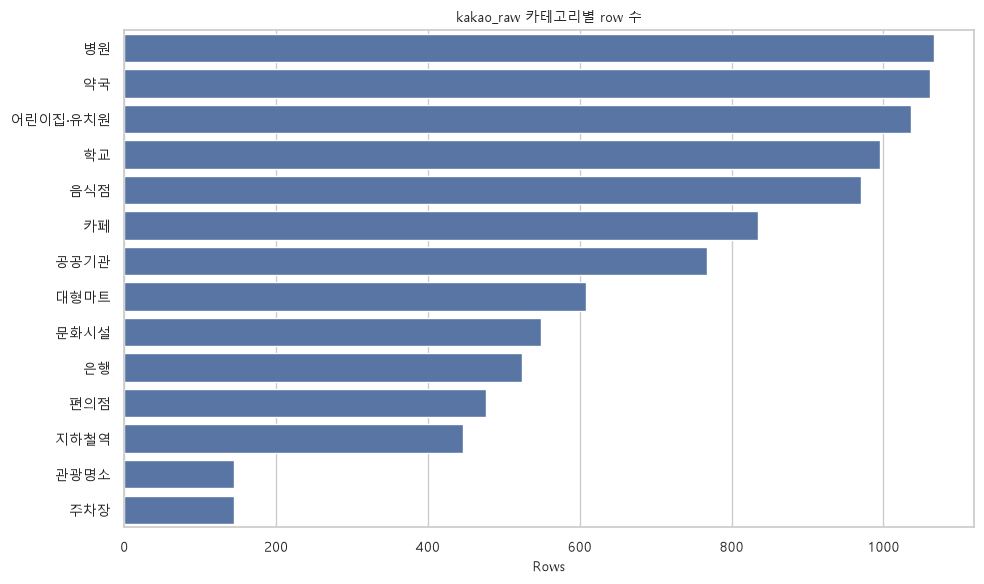

In [5]:
if kakao_gdf.empty:
    print("kakao_raw가 비어 있어 category 분포를 그릴 수 없습니다.")
else:
    kakao_query_counts = (
        kakao_gdf.groupby("query_key")
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
    )
    kakao_query_counts["category_code"] = kakao_query_counts["query_key"].str.replace("category=", "", regex=False)
    kakao_query_counts["category_name_ko"] = kakao_query_counts["category_code"].map(KAKAO_CATEGORY_CODE_NAME)
    display(kakao_query_counts)
    kakao_query_counts.to_csv(TABLE_DIR / "kakao_query_key_row_count.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=kakao_query_counts, x="row_count", y="category_name_ko")
    ax.set_title("kakao_raw 카테고리별 row 수")
    ax.set_xlabel("Rows")
    ax.set_ylabel("")
    apply_korean_font(ax)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "kakao_category_row_count.png", dpi=160)
    plt.show()

## 5. properties 컬럼 구조 확인

Kakao 장소 검색 결과에서 어떤 속성이 남아 있는지 확인한다. 현재 clean 단계에서는 `name`, `address`, `category_name`, `phone`, `place_url` 중심으로 저장된다.

In [6]:
if kakao_gdf.empty:
    kakao_flat = pd.DataFrame()
    kakao_prop_counts = pd.DataFrame()
    print("kakao_raw가 비어 있습니다.")
else:
    kakao_props = pd.json_normalize(kakao_gdf["properties"].apply(lambda x: x or {}).tolist())
    kakao_flat = pd.concat(
        [kakao_gdf.drop(columns=["properties"]).reset_index(drop=True), kakao_props],
        axis=1,
    )
    kakao_flat["category_code"] = kakao_flat["query_key"].str.replace("category=", "", regex=False)
    kakao_flat["category_name_ko"] = kakao_flat["category_code"].map(KAKAO_CATEGORY_CODE_NAME)

    kakao_prop_counts = (
        kakao_props.notna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "property", 0: "non_null_rows"})
    )
    print("properties columns:", len(kakao_props.columns))
    display(kakao_flat.head())
    display(kakao_prop_counts)
    kakao_prop_counts.to_csv(TABLE_DIR / "kakao_property_non_null_counts.csv", index=False, encoding="utf-8-sig")

properties columns: 5


,kakao_raw_id,query_key,fetched_at,geom,name,phone,address,place_url,category_name,category_code,category_name_ko
0,1,category=MT1,2026-06-24 06:20:30.636184,POINT (126.86545 37.68995),이마트에브리데이 관산동점,031-969-9690,경기 고양시 덕양구 관산동 112-22,http://place.map.kakao.com/19780153,"가정,생활 > 슈퍼마켓 > 대형슈퍼 > 이마트에브리데이",MT1,대형마트
1,2,category=MT1,2026-06-24 06:20:30.636184,POINT (126.86391 37.68721),벽제농협 로컬푸드직매장,031-962-1873,경기 고양시 덕양구 관산동 226-2,http://place.map.kakao.com/27538777,"가정,생활 > 슈퍼마켓 > 대형슈퍼 > 하나로마트",MT1,대형마트
2,3,category=MT1,2026-06-24 06:20:30.636184,POINT (126.84487 37.66545),고양축협하나로마트 본점,031-965-0018,경기 고양시 덕양구 성사동 620-1,http://place.map.kakao.com/9650628,"가정,생활 > 슈퍼마켓 > 대형슈퍼 > 하나로마트",MT1,대형마트
3,4,category=MT1,2026-06-24 06:20:30.636184,POINT (126.83857 37.65839),홈플러스익스프레스 고양성사점,031-968-8545,경기 고양시 덕양구 성사동 501-2,http://place.map.kakao.com/12375701,"가정,생활 > 슈퍼마켓 > 대형슈퍼 > 홈플러스익스프레스",MT1,대형마트
4,5,category=MT1,2026-06-24 06:20:30.636184,POINT (126.83851 37.65723),원당농협로컬푸드직매장 성사점,031-966-6251,경기 고양시 덕양구 성사동 505,http://place.map.kakao.com/24767249,"가정,생활 > 슈퍼마켓 > 대형슈퍼 > 하나로마트",MT1,대형마트


,property,non_null_rows
0,name,9624
1,phone,9624
2,address,9624
3,place_url,9624
4,category_name,9624


## 6. 주요 설명 컬럼 결측률 확인

Kakao는 place 기반 API이므로 `name`, `address`, `category_name`, `place_url`이 중요하다. `phone`은 없는 장소가 많을 수 있으므로 score 근거보다는 보조 설명 컬럼으로만 본다.

In [7]:
if kakao_flat.empty:
    kakao_missing_summary = pd.DataFrame()
    print("kakao_flat이 비어 있습니다.")
else:
    core_cols = [c for c in ["name", "address", "category_name", "phone", "place_url"] if c in kakao_flat.columns]
    rows = []
    for query_key, group in kakao_flat.groupby("query_key"):
        for col in core_cols:
            missing_rate = float(group[col].isna().mean())
            rows.append({
                "query_key": query_key,
                "category_name_ko": group["category_name_ko"].iloc[0],
                "column": col,
                "missing_rows": int(group[col].isna().sum()),
                "missing_rate": missing_rate,
                "usage_note": "핵심 해석 가능" if missing_rate <= 0.05 else "보조 해석 주의",
            })
    kakao_missing_summary = pd.DataFrame(rows)
    display(kakao_missing_summary)
    kakao_missing_summary.to_csv(TABLE_DIR / "kakao_core_column_missing_summary.csv", index=False, encoding="utf-8-sig")

,query_key,category_name_ko,column,missing_rows,missing_rate,usage_note
0,category=AT4,관광명소,name,0,0.0,핵심 해석 가능
1,category=AT4,관광명소,address,0,0.0,핵심 해석 가능
2,category=AT4,관광명소,category_name,0,0.0,핵심 해석 가능
3,category=AT4,관광명소,phone,0,0.0,핵심 해석 가능
4,category=AT4,관광명소,place_url,0,0.0,핵심 해석 가능
...,...,...,...,...,...,...
65,category=SW8,지하철역,name,0,0.0,핵심 해석 가능
66,category=SW8,지하철역,address,0,0.0,핵심 해석 가능
67,category=SW8,지하철역,category_name,0,0.0,핵심 해석 가능
68,category=SW8,지하철역,phone,0,0.0,핵심 해석 가능


## 7. geometry 품질 및 서울 bbox 포함 여부

Kakao raw는 point geometry다. 서울 bbox 밖 좌표가 많으면 격자/반경 수집 때문에 서울 외곽 결과가 섞인 것으로 볼 수 있다.

In [8]:
if kakao_gdf.empty:
    kakao_geo_quality = pd.DataFrame()
    kakao_bbox_quality = pd.DataFrame()
    print("kakao_gdf가 비어 있습니다.")
else:
    kakao_points = add_point_quality_columns(kakao_gdf)
    kakao_geo_quality = pd.DataFrame([{
        "total_rows": len(kakao_points),
        "null_geometry_rows": int(kakao_points.geometry.isna().sum()),
        "valid_geometry_rows": int(kakao_points.geometry.is_valid.sum()),
        "invalid_geometry_rows": int((~kakao_points.geometry.is_valid).sum()),
        "within_seoul_bbox_rows": int(kakao_points["within_seoul_bbox"].sum()),
        "outside_seoul_bbox_rows": int((~kakao_points["within_seoul_bbox"]).sum()),
        "within_seoul_bbox_rate": float(kakao_points["within_seoul_bbox"].mean()),
    }])

    kakao_bbox_quality = kakao_points.groupby("query_key").agg(
        total_rows=("kakao_raw_id", "count"),
        within_seoul_bbox_rows=("within_seoul_bbox", "sum"),
    ).reset_index()
    kakao_bbox_quality["within_seoul_bbox_rate"] = kakao_bbox_quality["within_seoul_bbox_rows"] / kakao_bbox_quality["total_rows"]
    kakao_bbox_quality["category_code"] = kakao_bbox_quality["query_key"].str.replace("category=", "", regex=False)
    kakao_bbox_quality["category_name_ko"] = kakao_bbox_quality["category_code"].map(KAKAO_CATEGORY_CODE_NAME)

    display(kakao_geo_quality)
    display(kakao_bbox_quality.sort_values("within_seoul_bbox_rate"))
    kakao_geo_quality.to_csv(TABLE_DIR / "kakao_geometry_quality.csv", index=False, encoding="utf-8-sig")
    kakao_bbox_quality.to_csv(TABLE_DIR / "kakao_bbox_quality_by_query_key.csv", index=False, encoding="utf-8-sig")

,total_rows,null_geometry_rows,valid_geometry_rows,invalid_geometry_rows,within_seoul_bbox_rows,outside_seoul_bbox_rows,within_seoul_bbox_rate
0,9624,0,9624,0,9324,300,0.968828


,query_key,total_rows,within_seoul_bbox_rows,within_seoul_bbox_rate,category_code,category_name_ko
0,category=AT4,145,138,0.951724,AT4,관광명소
9,category=PM9,1061,1012,0.953817,PM9,약국
6,category=HP8,1066,1020,0.956848,HP8,병원
10,category=PO3,767,734,0.956975,PO3,공공기관
8,category=PK6,145,139,0.958621,PK6,주차장
4,category=CT1,549,528,0.961749,CT1,문화시설
1,category=BK9,524,504,0.961832,BK9,은행
12,category=SC4,995,960,0.964824,SC4,학교
7,category=MT1,608,587,0.965461,MT1,대형마트
13,category=SW8,446,433,0.970852,SW8,지하철역


## 8. 중복 후보 확인

Kakao 수집은 여러 격자 중심점에서 같은 장소가 반복 검색될 수 있다. 같은 query_key 안에서 좌표 또는 `place_url`이 중복되는지 확인한다.

In [9]:
if kakao_flat.empty:
    kakao_duplicate_summary = pd.DataFrame()
    print("kakao_flat이 비어 있습니다.")
else:
    kakao_points = add_point_quality_columns(kakao_gdf)[["kakao_raw_id", "lon_round6", "lat_round6"]]
    kakao_flat_with_coord = kakao_flat.merge(kakao_points, on="kakao_raw_id", how="left")
    kakao_flat_with_coord["coord_duplicate_in_query"] = kakao_flat_with_coord.duplicated(
        subset=["query_key", "lat_round6", "lon_round6"], keep=False
    )

    if "place_url" in kakao_flat_with_coord.columns:
        kakao_flat_with_coord["place_url_duplicate_in_query"] = kakao_flat_with_coord.duplicated(
            subset=["query_key", "place_url"], keep=False
        )
    else:
        kakao_flat_with_coord["place_url_duplicate_in_query"] = False

    kakao_duplicate_summary = kakao_flat_with_coord.groupby(["query_key", "category_name_ko"]).agg(
        total_rows=("kakao_raw_id", "count"),
        duplicate_coord_rows=("coord_duplicate_in_query", "sum"),
        duplicate_place_url_rows=("place_url_duplicate_in_query", "sum"),
    ).reset_index()
    kakao_duplicate_summary["duplicate_coord_rate"] = kakao_duplicate_summary["duplicate_coord_rows"] / kakao_duplicate_summary["total_rows"]
    kakao_duplicate_summary["duplicate_place_url_rate"] = kakao_duplicate_summary["duplicate_place_url_rows"] / kakao_duplicate_summary["total_rows"]

    display(kakao_duplicate_summary.sort_values("duplicate_place_url_rate", ascending=False))
    kakao_duplicate_summary.to_csv(TABLE_DIR / "kakao_duplicate_summary.csv", index=False, encoding="utf-8-sig")

,query_key,category_name_ko,total_rows,duplicate_coord_rows,duplicate_place_url_rows,duplicate_coord_rate,duplicate_place_url_rate
0,category=AT4,관광명소,145,0,0,0.000000,0.0
1,category=BK9,은행,524,2,0,0.003817,0.0
2,category=CE7,카페,835,6,0,0.007186,0.0
3,category=CS2,편의점,477,0,0,0.000000,0.0
4,category=CT1,문화시설,549,0,0,0.000000,0.0
5,category=FD6,음식점,970,2,0,0.002062,0.0
6,category=HP8,병원,1066,45,0,0.042214,0.0
7,category=MT1,대형마트,608,0,0,0.000000,0.0
8,category=PK6,주차장,145,0,0,0.000000,0.0
9,category=PM9,약국,1061,6,0,0.005655,0.0


## 9. category_name 일관성 확인

`query_key`의 카테고리 코드와 Kakao가 반환한 `category_name`의 상위 분류가 얼마나 일관적인지 본다.

In [10]:
if kakao_flat.empty or "category_name" not in kakao_flat.columns:
    kakao_category_consistency = pd.DataFrame()
    print("category_name을 확인할 수 없습니다.")
else:
    kakao_flat["category_top"] = kakao_flat["category_name"].astype(str).str.split(">").str[0].str.strip()
    kakao_category_consistency = (
        kakao_flat.groupby(["query_key", "category_name_ko", "category_top"])
        .size()
        .reset_index(name="row_count")
        .sort_values(["query_key", "row_count"], ascending=[True, False])
    )
    display(kakao_category_consistency)
    kakao_category_consistency.to_csv(TABLE_DIR / "kakao_category_name_consistency.csv", index=False, encoding="utf-8-sig")

,query_key,category_name_ko,category_top,row_count
1,category=AT4,관광명소,여행,138
0,category=AT4,관광명소,"스포츠,레저",7
2,category=BK9,은행,"금융,보험",524
4,category=CE7,카페,음식점,749
3,category=CE7,카페,"가정,생활",86
5,category=CS2,편의점,"가정,생활",477
6,category=CT1,문화시설,"문화,예술",549
8,category=FD6,음식점,음식점,969
7,category=FD6,음식점,"가정,생활",1
10,category=HP8,병원,"의료,건강",1016


## 10. layer/score 직접 반영 여부 정리

현재 Kakao raw는 `kakao_raw_id`로 layer table에 직접 연결되는 구조가 아니다. 따라서 최종 score 산정의 고정 DB라기보다 주변 장소 검색 품질 확인 또는 서비스 표시용 POI 후보로 보는 것이 안전하다.

In [11]:
kakao_layer_usage_plan = pd.DataFrame([
    {
        "item": "kakao_raw_id FK",
        "current_status": "layer table에 직접 FK 없음",
        "meaning": "raw → layer 반영률을 DB 관계로 검증하기 어려움",
        "next_action": "Kakao 기반 layer를 만들 경우 FK 컬럼 또는 mapping table 필요",
    },
    {
        "item": "score 근거성",
        "current_status": "검색 API 기반 POI 후보",
        "meaning": "공식 전수 데이터가 아니므로 자치구 비교 score 주지표로 부적절",
        "next_action": "편의시설 접근성 보조 지표 또는 지도 표시용으로 제한",
    },
    {
        "item": "최신성",
        "current_status": "fetched_at만 저장",
        "meaning": "Kakao 장소 정보 자체의 수정일은 알 수 없음",
        "next_action": "재수집 주기와 샘플 live API 비교 검증 필요",
    },
])

display(kakao_layer_usage_plan)
kakao_layer_usage_plan.to_csv(TABLE_DIR / "kakao_layer_usage_plan.csv", index=False, encoding="utf-8-sig")

,item,current_status,meaning,next_action
0,kakao_raw_id FK,layer table에 직접 FK 없음,raw → layer 반영률을 DB 관계로 검증하기 어려움,Kakao 기반 layer를 만들 경우 FK 컬럼 또는 mapping table 필요
1,score 근거성,검색 API 기반 POI 후보,공식 전수 데이터가 아니므로 자치구 비교 score 주지표로 부적절,편의시설 접근성 보조 지표 또는 지도 표시용으로 제한
2,최신성,fetched_at만 저장,Kakao 장소 정보 자체의 수정일은 알 수 없음,재수집 주기와 샘플 live API 비교 검증 필요


## 11. 1차 해석 메모

이 노트북에서 최종적으로 판단할 것:

- Kakao raw가 카테고리별로 얼마나 편향되어 있는가
- 좌표가 서울 bbox 안에 들어오는가
- 격자 수집으로 인한 중복이 큰가
- 설명 컬럼이 지도 표시/검색 품질 검증에 충분한가
- 현재 layer/score에 직접 연결되어 있는가

Kakao raw는 검색 API 결과이므로 최종 score 주 데이터보다는 POI 보조 검증/지도 표시/사용자 주변 검색 품질 확인용으로 보는 것이 안전하다.